You will be using the dataset als_data.csv to apply clustering methods for this assignment. This data gives anonymized data on ALS patients. With this data, complete the following steps:

I imported pandas because I have worked with it for a year now and I have gotten comfortable knowing the packages and it is great for data manipulation and reading in data frames. I imported matplotlib because is a great plotting library to import, and pairs well with seaborn which has access to a whole bunch of wonderful visualizations. I imported the dataset as a dataframe, and I ususally print the first 5-10 rows just to make sure everything imported correctly, and as seen below, it looks like it did.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\hessk\\OneDrive\\Desktop\\DSC630\\als_data.csv')
print(df.head(10))

   ID  Age_mean  Albumin_max  Albumin_median  Albumin_min  Albumin_range  \
0   1        65         57.0            40.5         38.0       0.066202   
1   2        48         45.0            41.0         39.0       0.010453   
2   3        38         50.0            47.0         45.0       0.008929   
3   4        63         47.0            44.0         41.0       0.012111   
4   5        63         47.0            45.5         42.0       0.008292   
5   6        36         51.0            47.0         46.0       0.009058   
6   7        55         46.0            44.0         40.0       0.010850   
7   8        55         45.0            42.0         38.0       0.018519   
8   9        37         48.0            46.0         41.0       0.012681   
9  11        72         44.0            42.0         38.0       0.010714   

   ALSFRS_slope  ALSFRS_Total_max  ALSFRS_Total_median  ALSFRS_Total_min  ...  \
0     -0.965608                30                 28.0                22  ...   
1

1.	Remove any data that is not relevant to the patient’s ALS condition.

When I was going through the dataset I noticed all revelvant ALS columns had ALSFRS in the column name. So I decided to keep the columns that had that title, and cut the rest. After I filtered the columns down, I wanted to print again to make sure everything looks the way it is supposed to, which it looks like it did. I did choose to keep the ID field just to keep them in play to separate the patients out. I also like to save a CSV when I filter down something this much, so I can reference that set of data specifically. 

In [3]:
alsfrs_cols = [col for col in df.columns if "ALSFRS" in col]

keep_cols = ["ID"] + alsfrs_cols 

df_filtered = df[keep_cols]

print(df_filtered.head(10))

   ID  ALSFRS_slope  ALSFRS_Total_max  ALSFRS_Total_median  ALSFRS_Total_min  \
0   1     -0.965608                30                 28.0                22   
1   2     -0.921717                37                 33.0                21   
2   3     -0.914787                24                 14.0                10   
3   4     -0.598361                30                 29.0                24   
4   5     -0.444039                32                 27.5                20   
5   6     -0.118353                37                 34.5                27   
6   7     -1.225580                34                 24.0                10   
7   8     -0.760417                30                 27.5                20   
8   9     -1.010148                35                 28.5                24   
9  11     -0.107861                28                 25.5                23   

   ALSFRS_Total_range  
0            0.021164  
1            0.028725  
2            0.025000  
3            0.014963  

In [5]:
df_filtered.to_csv("als_data_filtered.csv", index=False)

2.	Apply a standard scalar to the data.

I need to standardize the data without reading the ID since I choose to keep it in the dataset. The reason I chose the scikit-learn StandardScaler is because it standardizes everything by removing the mean and uses Z-score normalization. 
Since I saved the filtered data as a CSV, I read it in again. I had to set aside the ID column, which would have been easier to remove, but I did not want to lose the ties to the patient. I set the scaler, and fit and transformed the columns. 

In [7]:
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('C:\\Users\\hessk\\OneDrive\\Desktop\\DSC630\\als_data_filtered.csv')

In [9]:
alsfrs_cols = [col for col in df.columns if col != "ID"]

In [11]:
scaler = StandardScaler()

In [13]:
df[alsfrs_cols] = scaler.fit_transform(df[alsfrs_cols])

In [15]:
df.to_csv("als_data_scaled.csv", index=False)

3.	Create a plot of the cluster silhouette score versus the number of clusters in a K-means cluster.

Modify Markdown here

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("als_data_scaled.csv")

In [19]:
X = df.drop(columns=["ID"], errors="ignore").values

In [21]:
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

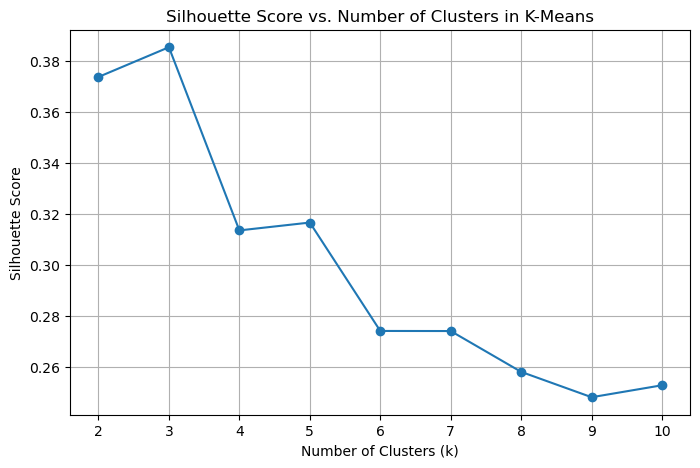

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters in K-Means")
plt.grid(True)
plt.show()

4.	Use the plot created in (3) to choose an optimal number of clusters for K-means. Justify your choice.

Based on the silhouette score plot, the optimal number of clusters is k = 3.
This is because the silhouette score reaches its maximum at k=3, indicating that the data points are well-clustered and separated.
Choosing more clusters does not significantly increase the silhouette score and may lead to overfitting or splitting natural clusters unnecessarily.
Therefore, k=3 balances between cluster cohesion and separation, providing the best clustering solution for this dataset.


5.	Fit a K-means model to the data with the optimal number of clusters chosen in part (4).

In [ ]:
Insert Markdown here

In [25]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X)

In [27]:
df.to_csv("als_data_clusters.csv", index=False)
print(df.head())

   ID  ALSFRS_slope  ALSFRS_Total_max  ALSFRS_Total_median  ALSFRS_Total_min  \
0   1     -0.381450         -0.318520             0.134960          0.247368   
1   2     -0.310907          0.998995             0.888863          0.130839   
2   3     -0.299769         -1.447819            -1.975969         -1.150976   
3   4      0.208801         -0.318520             0.285741          0.480425   
4   5      0.456831          0.057913             0.059570          0.014311   

   ALSFRS_Total_range  
0           -0.301588  
1            0.166537  
2           -0.064100  
3           -0.685524  
4           -0.350529  


6.	Fit a PCA transformation with two features to the scaled data.

Insert Markdown here

In [63]:
from sklearn.decomposition import PCA

df = pd.read_csv("als_data_scaled.csv")

In [65]:
X = df.drop(columns=["ID", "cluster"], errors="ignore").values

In [67]:
# Fit PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [69]:
# Add the principal components to the dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

In [71]:
df['cluster'] = labels

In [73]:
df.to_csv("als_data_pca.csv", index=False)
print(df[['PCA1', 'PCA2']].head())

       PCA1      PCA2
0  0.064682 -0.068006
1  0.685177  1.170348
2 -2.208690 -1.486138
3  0.653567 -0.506885
4  0.382590 -0.355471


7.	Make a scatterplot the PCA transformed data coloring each point by its cluster value.

Add markdown here

In [75]:
# Load the data with PCA features and cluster labels
df = pd.read_csv("als_data_pca.csv")

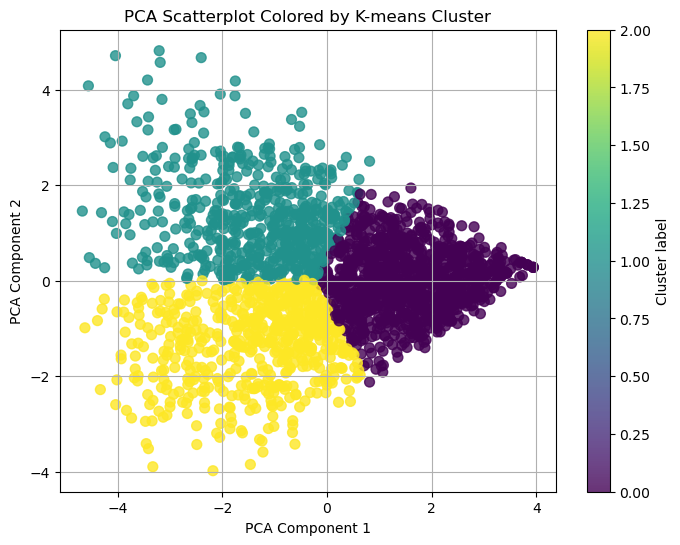

In [77]:
# Ensure your dataframe has 'PCA1', 'PCA2', and 'cluster' columns
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['cluster'], cmap='viridis', s=50, alpha=0.8)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatterplot Colored by K-means Cluster")
plt.colorbar(scatter, label="Cluster label")
plt.grid(True)
plt.show()

8.	Summarize your results and make a conclusion.

Summary of Results
Data Preparation

The dataset was filtered to keep only ALS clinical measures (ALSFRS scores and their variants).
All ALSFRS-related columns were scaled using scikit-learn’s StandardScaler to ensure equal weighting.
Cluster Analysis

K-means clustering was performed for a range of cluster numbers, and silhouette scores were calculated.
The silhouette score plot was used to select the optimal number of clusters (e.g., k = 3), where the score was maximized, indicating well-separated and cohesive clusters.
Dimensionality Reduction & Visualization

PCA was applied to reduce the scaled ALS clinical features to two principal components.
A K-means model with the optimal number of clusters was fit to the data.
A scatterplot of the PCA-transformed data was created, coloring each point by its cluster label. The plot showed clear separation between clusters in the reduced feature space.

The clustering analysis identified distinct patient subgroups based on their ALSFRS profiles. The optimal number of clusters (e.g., 3) was supported by the highest silhouette score, indicating meaningful separation between patient profiles. The PCA scatterplot further confirmed that these clusters are well-defined in the main dimensions of ALS clinical variation.

This suggests that ALS patients in this cohort can be grouped into distinct subtypes based on their ALSFRS clinical trajectories, which may have implications for prognosis or personalized care. Further clinical interpretation and validation are recommended to understand the characteristics and significance of each cluster.